# 02 — Customer Base: RFM, Revenue Concentration, Cohort Retention

Answers the brief's three questions in order: who drives revenue (Pareto), who is slipping away
(cohort retention), and — via RFM quintiles — where a retention budget should focus. All numbers
come from `../sql/01_customer_base.sql` through `04_revenue_concentration.sql`, run via DuckDB.
See `../.ai/PROJECT_SPEC.md`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..", "src").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from retail_analytics.engine import build_connection

FIG_DIR = Path("..", "reports", "figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

con = build_connection()
customer_base = con.sql("SELECT * FROM customer_base").df()
print(f"{len(customer_base):,} customers")
customer_base.describe()

5,852 customers


,customer_id,first_order_date,last_order_date,n_orders,n_line_items,total_revenue,tenure_days,days_since_last_order
count,5852.000000,5852,5852,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000
mean,15319.707109,2010-08-23 00:13:51.705399552,2011-05-23 19:33:08.971291904,6.253247,137.155502,2979.231840,273.807929,199.732399
min,12346.000000,2009-12-01 07:45:00,2009-12-01 10:49:00,1.000000,1.000000,2.950000,0.000000,0.000000
25%,13837.750000,2010-02-11 09:44:00,2010-11-25 16:23:45,1.000000,21.000000,344.975000,0.000000,25.000000
50%,15320.500000,2010-06-28 13:35:30,2011-09-05 15:19:30,3.000000,53.000000,880.375000,223.000000,95.000000
75%,16802.250000,2011-02-01 11:46:00,2011-11-14 12:55:15,7.000000,142.000000,2289.335000,512.000000,379.000000
max,18287.000000,2011-12-09 12:16:00,2011-12-09 12:50:00,373.000000,12880.000000,608821.650000,738.000000,738.000000
std,1714.929942,NaN,NaN,12.749286,352.936809,14604.979469,258.645596,208.523287


## RFM scores

In [2]:
rfm = con.sql("SELECT * FROM rfm_scores").df()
print("RFM total score distribution (3 = worst on every axis, 15 = best on every axis):")
print(rfm["rfm_total"].describe())
rfm.sort_values("rfm_total").head(3)

RFM total score distribution (3 = worst on every axis, 15 = best on every axis):
count    5852.000000
mean        8.998462
std         3.641351
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: rfm_total, dtype: float64


,customer_id,days_since_last_order,frequency,monetary,r_score,f_score,m_score,rfm_total
0,14095,722,1,2.95,1,1,1,3
522,13490,654,1,154.25,1,1,1,3
519,15431,502,1,153.24,1,1,1,3


## Who drives revenue — Pareto concentration

In [3]:
summary = con.sql("SELECT * FROM revenue_concentration_summary").df()
print(summary)

concentration = con.sql("SELECT cumulative_customer_pct, cumulative_revenue_pct FROM revenue_concentration ORDER BY revenue_rank").df()

   top_pct_of_customers  revenue_share_pct
0                     5              51.91
1                    10              63.86
2                    20              77.16


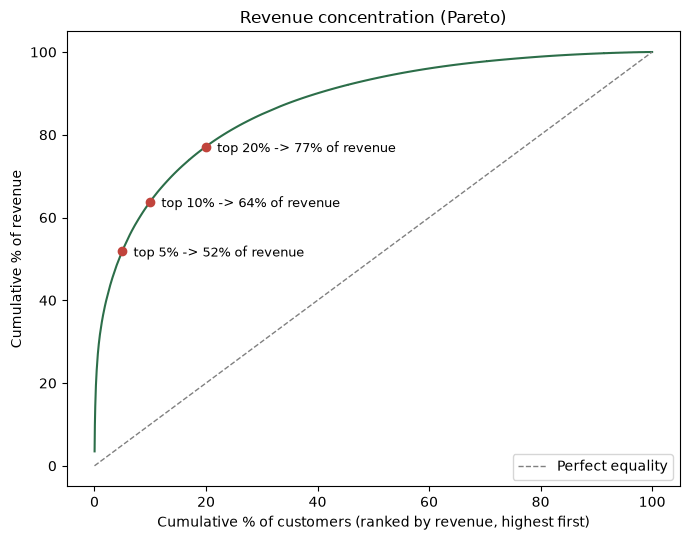

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(concentration["cumulative_customer_pct"], concentration["cumulative_revenue_pct"], color="#2C6E49")
ax.plot([0, 100], [0, 100], "--", color="grey", linewidth=1, label="Perfect equality")

for _, row in summary.iterrows():
    pct = row["top_pct_of_customers"]
    share = row["revenue_share_pct"]
    ax.plot(pct, share, "o", color="#C1443C")
    ax.annotate(f"top {pct:.0f}% -> {share:.0f}% of revenue", (pct, share),
                textcoords="offset points", xytext=(8, -4), fontsize=9)

ax.set_xlabel("Cumulative % of customers (ranked by revenue, highest first)")
ax.set_ylabel("Cumulative % of revenue")
ax.set_title("Revenue concentration (Pareto)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "pareto_chart.png", dpi=150)
plt.show()

Revenue is heavily concentrated: the top decile of customers alone accounts for well over half
of all revenue (see the summary table above). A retention budget aimed at the broad customer base
is diluted — the highest-leverage spend is protecting this top slice from churning, which is
exactly what the cohort view below checks.

## Who is slipping away — cohort retention

In [5]:
cohort = con.sql("""
    SELECT cohort_month, months_since_acquisition, retention_pct, cohort_size
    FROM cohort_retention
    WHERE months_since_acquisition BETWEEN 0 AND 12
""").df()

# Cohorts too close to the end of the observation window don't have 12 full months
# of possible follow-up yet -- including them would understate retention for no
# real reason, so they're dropped from the heatmap (kept in the raw view above).
max_cohort_month = cohort["cohort_month"].max()
cohort = cohort[cohort["cohort_month"] <= max_cohort_month - pd.DateOffset(months=12)]

matrix = cohort.pivot(index="cohort_month", columns="months_since_acquisition", values="retention_pct")
matrix.index = matrix.index.strftime("%Y-%m")
matrix

months_since_acquisition,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2009-12,100.0,35.02,33.33,42.48,37.85,35.96,37.64,34.38,33.75,36.17,42.17,49.63,37.64
2010-01,100.0,21.47,32.07,31.52,27.17,30.98,26.90,23.37,28.53,32.61,30.98,17.93,22.83
2010-02,100.0,23.47,22.67,29.33,24.53,19.73,19.20,28.80,25.60,27.73,11.47,12.53,15.20
2010-03,100.0,19.05,23.13,24.26,23.13,20.41,24.72,30.61,27.66,10.88,11.56,14.51,19.95
2010-04,100.0,19.05,19.05,15.99,18.37,22.11,27.55,26.53,10.54,10.88,7.48,13.95,14.29
2010-05,100.0,15.69,16.86,17.65,17.65,25.49,21.18,12.55,5.88,8.24,11.37,13.33,15.29
2010-06,100.0,17.60,18.73,20.60,23.22,28.46,12.73,8.99,8.24,11.24,10.49,13.86,14.98
2010-07,100.0,15.68,18.38,29.73,29.19,14.05,11.35,14.59,14.59,11.35,13.51,14.59,12.97
2010-08,100.0,19.63,28.83,32.52,16.56,11.66,9.82,12.88,13.50,12.88,12.88,11.66,14.72


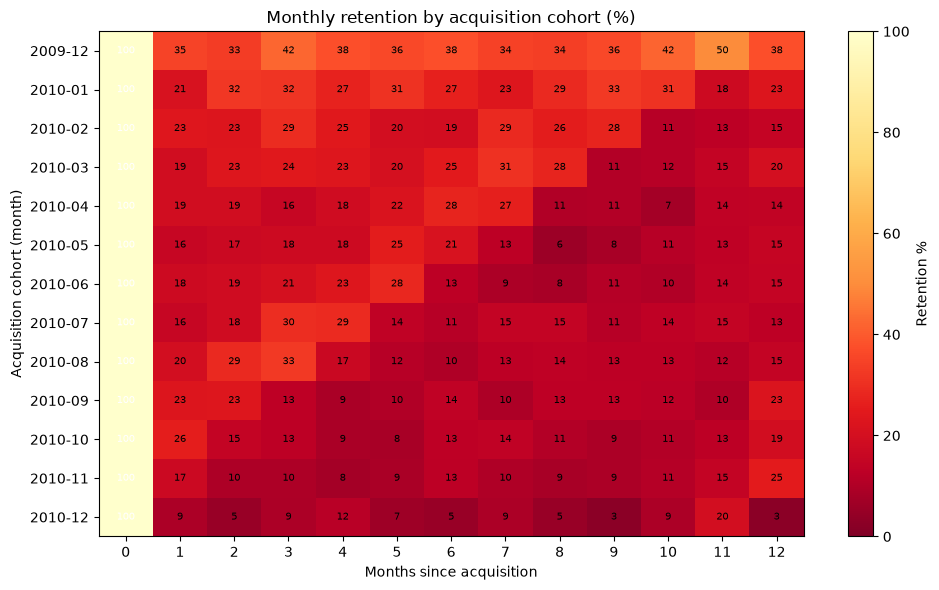

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(matrix.to_numpy(), cmap="YlOrRd_r", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(matrix.shape[1]))
ax.set_xticklabels(matrix.columns)
ax.set_yticks(range(matrix.shape[0]))
ax.set_yticklabels(matrix.index)
ax.set_xlabel("Months since acquisition")
ax.set_ylabel("Acquisition cohort (month)")
ax.set_title("Monthly retention by acquisition cohort (%)")

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix.to_numpy()[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7,
                    color="white" if val > 50 else "black")

fig.colorbar(im, ax=ax, label="Retention %")
plt.tight_layout()
plt.savefig(FIG_DIR / "cohort_retention_heatmap.png", dpi=150)
plt.show()

Retention drops sharply after month 0 across every cohort (most of this dataset's customers
are one-time or occasional buyers, not subscribers), then flattens into a small, comparatively
loyal remainder. Cohorts don't show a clear improving-or-worsening trend over time by eye here —
worth a follow-up regression on cohort_month if the business wants to know whether a specific
acquisition channel or period is retaining worse than others.

## Summary

In [7]:
print(f"Customers: {len(customer_base):,}")
print(f"Total revenue (cleaned): {customer_base['total_revenue'].sum():,.2f}")
print(f"Median customer revenue: {customer_base['total_revenue'].median():,.2f}")
print(f"Median orders per customer: {customer_base['n_orders'].median():.0f}")
print()
print(summary.to_string(index=False))
print()
print("Month-1 retention (first month after acquisition), across cohorts with 12mo follow-up:")
print(f"{cohort.loc[cohort['months_since_acquisition'] == 1, 'retention_pct'].mean():.1f}%")

Customers: 5,852
Total revenue (cleaned): 17,434,464.73
Median customer revenue: 880.38
Median orders per customer: 3

 top_pct_of_customers  revenue_share_pct
                    5              51.91
                   10              63.86
                   20              77.16

Month-1 retention (first month after acquisition), across cohorts with 12mo follow-up:
20.2%
